# Regresión y AB testing

En este notebook abordaremos cómo a partir de datos observacionales podemos detectar efectos causales. Particularmente abordaremos técnicas de regresión.

1. Vamos a *suponer* un proceso generador de los datos de tal forma que podamos explicar cómo abordar la causalidad mediante un modelo de A/B testing y un modelo de regresión lineal. Tomemos el siguiente ejemplo:

## Queremos medir el efecto causal (causal effect) de un programa de capacitación (D) - *tratamiento*- , en el ingreso anual de trabajadores (Y), donde tenemos además dos variables que influyen en el ingreso:


* Educación (medida en años, X1)
* Experiencia laboral (medida en años, X2)

#### 1.1 Parámetros

Definimos los parámetros “verdaderos”  de la siguiente forma:

* Intercepto $\beta_0: 20$  (ingreso anual base en miles de USD).
* Efecto del tratamiento (programa de capacitación) en miles de USD: $\tau = 5$ (el incremento en el ingreso debido al programa de capacitación es de 5k USD, en promedio, manteniendo lo demás constante).
* Efecto de la educación: $\beta_1: 1$ (cada año adicional de escolaridad/educación incrementa el ingreso anual en 1k USD)
* Efecto de la experiencia: $\beta_2: 2$ (cada año adicional de experiencia incrementa el ingreso anual en 2k USD)
* Varianza del error: $\sigma=1.5$.

Veremos si los modelos estadísticos recuperan los parámetros verdaderos.

In [ ]:
!pip install numpy pandas statsmodels

In [ ]:
pip install seaborn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

#### 1.2 Simularemos X1 , X2 y Asignación al Tratamiento.


En la práctica, las personas pueden apuntarse o ser seleccionadas para el programa de forma tal que la asignación podría estar correlacionada con su educación y/o experiencia. Por ejemplo, podemos asumir que la **probabilidad de recibir tratamiento** $P(D=1)$ es mayor para aquellos que tienen mayor educación o experiencia:

- Para el A/B testing asumiremos una distribución binomial simple.
- Para la regresión consideraremos una distribución logistica como sigue:

$$
P(D=1|X_1,X_2) = logistic(-4 + 0.2X_1 + 0.15X_2)
$$

o equivalentemente:

$$
P(D=1) = \frac{1}{1+\exp[-(-4 + 0.2X_1 + 0.15X_2)]}
$$

#### 1.3 Generamos el Outcome ($Y$) mediante el siguiente proceso:

$$
Y
= \beta_0
+ \tau \, D
+ \beta_1 \, X_1
+ \beta_2 \, X_2
+ \varepsilon
$$

donde $\varepsilon \sim N(0, \sigma^2)$

---
##  2. A/B Testing

Antes de introducir el problema de los *confounders* y cómo abordarlo con regresión, vale la pena preguntarse:

 **¿cuál sería la forma ideal de estimar el efecto causal del programa de capacitación?**

La respuesta es el **A/B Testing** (también llamado experimento controlado aleatorizado o RCT: *Randomized Controlled Trial*).


### ¿Qué es el A/B Testing?

El A/B testing es un diseño experimental en el que se asigna **aleatoriamente** a los individuos a uno de dos grupos:

- **Grupo Control, $D=0$:** No recibe el tratamiento (no toma el programa de capacitación).
- **Grupo Tratamiento, $D=1$:** Sí recibe el tratamiento (toma el programa).

La clave es la palabra **aleatoriamente**. Cuando la asignación es completamente al azar:

$$P(D=1 \mid X_1, X_2) = P(D=1) = 0.5 = P (D=0| X_1, X_2) = P(D=0)$$

Es decir, la probabilidad de recibir el tratamiento es **independiente** de cualquier característica del individuo
(educación, experiencia, etc.). Esto rompe cualquier correlación entre $D$ y las variables de confusión $X_1, X_2$.


### ¿Por qué funciona?

Con asignación aleatoria, los dos grupos son **estadísticamente equivalentes** en promedio antes del tratamiento.
 Cualquier diferencia en el *outcome* $Y$ después del experimento **sólo puede atribuirse al tratamiento $D$**,  no a diferencias preexistentes entre los grupos.

Formalmente, la aleatorización garantiza el supuesto de **independencia condicional** (o *ignorabilidad*):

$$\{Y(0), Y(1)\} \perp D$$


donde $Y(0)$ e $Y(1)$ son los **resultados potenciales** (*potential outcomes*) de cada individuo bajo control y tratamiento respectivamente.
Bajo este supuesto, el estimador más simple del efecto causal es la **diferencia de medias**:

$$\hat{\tau}_{ATE} = \bar{Y}_{\text{tratados}} - \bar{Y}_{\text{controles}} = E[Y \mid D=1] - E[Y \mid D=0]$$

Y este estimador es **insesgado** para el **ATE (*Average Treatment Effect*)**.


### Contrastando con el escenario observacional

En el notebook, el escenario **sin A/B testing** (que desarrollamos más adelante) es uno donde la asignación al tratamiento **no es aleatoria**: las personas con más educación y experiencia tienen mayor probabilidad de inscribirse al programa. Esto crea un sesgo de selección que contamina la estimación del efecto causal.



### 2.1 Simulación del A/B Test

Usamos los **mismos parámetros verdaderos** del proceso generador de datos, pero ahora asignamos el tratamiento
**completamente al azar** (con probabilidad 0.5), ignorando $X_1$ y $X_2$.

Modelaremos $$
Y_{A/B}
= \beta_0
+ \tau \, D
+ \beta_1 \, X_1
+ \beta_2 \, X_2
+ \varepsilon
$$


Esto nos permitirá comparar la estimación que obtenemos bajo el escenario ideal (A/B test) versus el escenario con confounders.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

np.random.seed(42)  # semilla para reproducibilidad

N_ab = 500  # tamaño de la muestra

# Parámetros verdaderos
beta0 = 20   ### Intercepto real
tau   = 5     # efecto causal verdadero que queremos recuperar
beta1 = 1
beta2 = 2
sigma = 1.5

# Covariables (educación y experiencia)
X1_ab = np.random.uniform(8, 16, size=N_ab).round() ## En años de estudio
X2_ab = np.random.uniform(0, 10, size=N_ab).round() ## En años de experiencia

# A/B testing:

# DIFERENCIA CLAVE CON LA REGRESIÓN : Asignación ALEATORIa

# P(D=1) = 0.5 para todos, independiente de X1 y X2

D_ab = np.random.binomial(n=1, p=0.5, size=N_ab)  ### ¿Por qué la asignación debe ser binomial?

# Outcome generado por el mismo proceso verdadero
eps_ab = np.random.normal(0, sigma, size=N_ab) ## Término de error normal

Y_ab   = beta0 + tau*D_ab + beta1*X1_ab + beta2*X2_ab + eps_ab

# DataFrame del experimento A/B
ab_data = pd.DataFrame({'Y': Y_ab, 'D': D_ab, 'X1': X1_ab, 'X2': X2_ab})

print(f"Tamaño total: {N_ab} observaciones")
print(f"Grupo tratamiento (D=1): {D_ab.sum()} observaciones")
print(f"Grupo control (D=0): {(1-D_ab).sum()} observaciones")
print()
print(ab_data.head())


Tamaño total: 500 observaciones
Grupo tratamiento (D=1): 262 observaciones
Grupo control (D=0): 238 observaciones

           Y  D    X1   X2
0  41.250891  0  11.0  7.0
1  54.436414  1  16.0  5.0
2  42.915641  1  14.0  3.0
3  51.531902  1  13.0  8.0
4  49.533856  1   9.0  7.0


### 2.2 Verificación del Balance Pre-Tratamiento

Una de las ventajas del A/B testing es que, por construcción, los grupos deben ser similares en las covariables **antes** del tratamiento.
Verificamos esto comparando las medias de $X_1$ (educación) y $X_2$ (experiencia) entre grupos.

Aquí hacemos una hipótesis $H_0 = \mu_{D=1} = \mu_{D=0}  $ y comprobamos que es el caso.

Variable      Media Trat.   Media Control    p-value
X1                 12.053          11.920      0.540
X2                  4.733           4.891      0.539
H0: las medias son iguales entre grupos.
Un p-value alto (>0.05) indica balance: NO se rechaza H0.


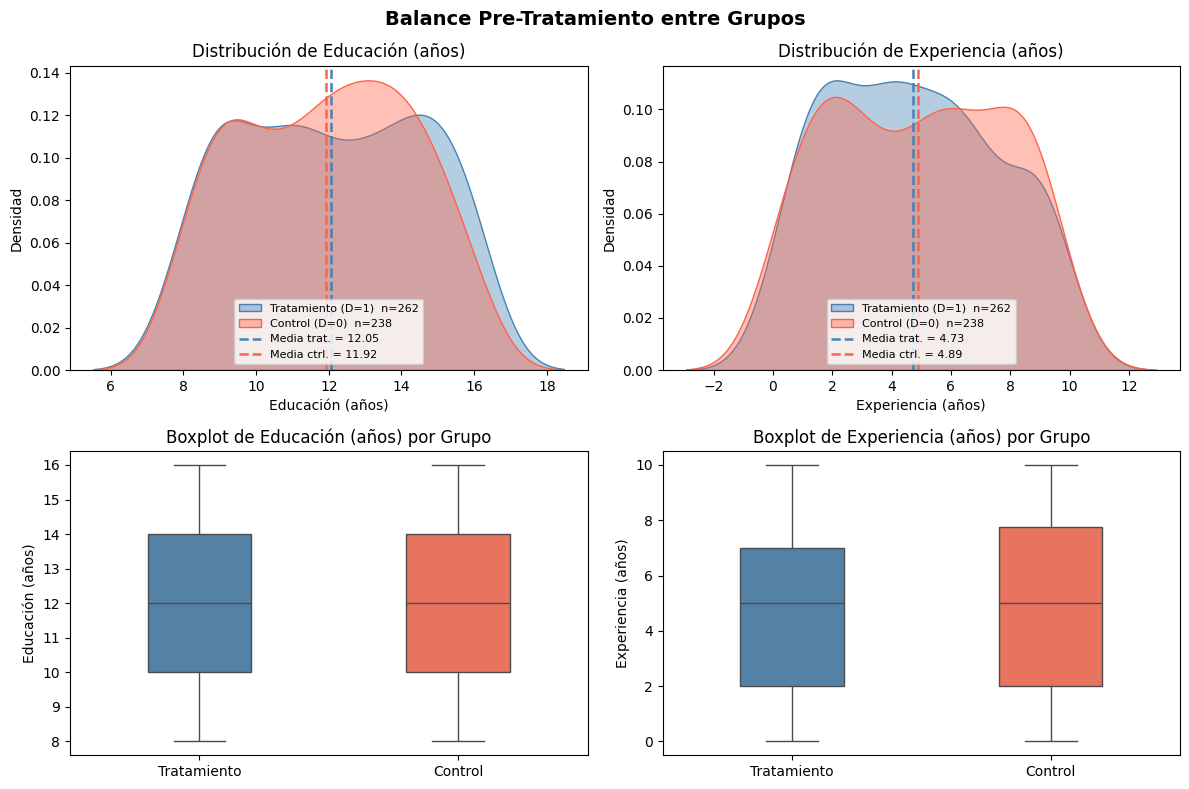

In [ ]:
# ============================================================
# ¿son los grupos comparables antes del tratamiento?
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

treated_ab = ab_data[ab_data['D'] == 1]
control_ab = ab_data[ab_data['D'] == 0]

print("=" * 55)
print(f"{'Variable':<12} {'Media Trat.':>12} {'Media Control':>15} {'p-value':>10}")
print("=" * 55)

for var in ['X1', 'X2']:
    t_stat, p_val = stats.ttest_ind(treated_ab[var], control_ab[var])
    print(f"{var:<12} {treated_ab[var].mean():>12.3f} {control_ab[var].mean():>15.3f} {p_val:>10.3f}")

print("=" * 55)
print("H0: las medias son iguales entre grupos.") ### <-- IMPORTANTE
print("Un p-value alto (>0.05) indica balance: NO se rechaza H0.")



# Visualización del balance
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Balance Pre-Tratamiento entre Grupos', fontsize=14, fontweight='bold')

for col, (var, label) in enumerate(zip(['X1', 'X2'], ['Educación (años)', 'Experiencia (años)'])):

    # --- Fila 0: KDE (curva suavizada, más fácil de comparar que histograma) ---
    ax = axes[0, col]
    sns.kdeplot(data=treated_ab, x=var, ax=ax, color='steelblue',
                fill=True, alpha=0.4, label=f'Tratamiento (D=1)  n={len(treated_ab)}')
    sns.kdeplot(data=control_ab, x=var, ax=ax, color='tomato',
                fill=True, alpha=0.4, label=f'Control (D=0)  n={len(control_ab)}')

    # Líneas verticales de las medias
    ax.axvline(treated_ab[var].mean(), color='steelblue', linestyle='--', linewidth=1.8,
               label=f'Media trat. = {treated_ab[var].mean():.2f}')
    ax.axvline(control_ab[var].mean(), color='tomato', linestyle='--', linewidth=1.8,
               label=f'Media ctrl. = {control_ab[var].mean():.2f}')
    ax.set_title(f'Distribución de {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

    # --- Fila 1: Boxplot lado a lado ---
    ax2 = axes[1, col]
    plot_df = pd.DataFrame({
        label: pd.concat([treated_ab[var], control_ab[var]]).values,
        'Grupo': ['Tratamiento']*len(treated_ab) + ['Control']*len(control_ab)
    })
    sns.boxplot(data=plot_df, x='Grupo', y=label, ax=ax2, hue='Grupo',
                palette={'Tratamiento': 'steelblue', 'Control': 'tomato'},
                width=0.4, legend=False )
    ax2.set_title(f'Boxplot de {label} por Grupo')
    ax2.set_xlabel('')
    ax2.set_ylabel(label)

plt.tight_layout()
plt.show()

### 2.3 Estimación del Efecto Causal: Diferencia de Medias

Con asignación aleatoria, el estimador más sencillo y válido del ATE es simplemente la **diferencia de medias del outcome** entre grupos. Acompañamos esta estimación con una prueba de hipótesis (t-test de dos muestras independientes).

**Hipótesis:**
- $H_0$: El programa de capacitación no tiene efecto ($\tau = 0$, i.e., $E[Y|D=1] = E[Y|D=0]$)
- $H_1$: El programa sí tiene efecto ($\tau \neq 0$)



In [ ]:
# ============================================================
# Estimación del Average Treatment Effect: diferencia de medias + t-test
# ============================================================

mean_treated = treated_ab['Y'].mean()
mean_control = control_ab['Y'].mean()
ate_estimate = mean_treated - mean_control  ### Cálculo del ATE

t_stat, p_value = stats.ttest_ind(treated_ab['Y'], control_ab['Y']) ### Inferencia

# Intervalo de confianza al 95% (aproximación Normal)
n_t = len(treated_ab)
n_c = len(control_ab)
se  = np.sqrt(treated_ab['Y'].var(ddof=1)/n_t + control_ab['Y'].var(ddof=1)/n_c) ### El error estádnar de la diferencia de medias
ci_low  = ate_estimate - 1.96 * se ### Los extremos del intervalo de confianza
ci_high = ate_estimate + 1.96 * se

print("=" * 50)
print(" RESULTADOS DEL A/B TEST")
print("=" * 50)
print(f"  Media Y (Tratamiento):     {mean_treated:.3f}")
print(f"  Media Y (Control):         {mean_control:.3f}")
print(f"  Efecto estimado (ATE):     {ate_estimate:.3f}")
print(f"  Efecto verdadero (tau):    {tau:.3f}")
print(f"  Error de estimación:       {abs(ate_estimate - tau):.3f}")
print("-" * 50)
print(f"  Estadístico t:             {t_stat:.3f}")
print(f"  P-value:                   {p_value:.4f}")
print(f"  IC 95%:                    [{ci_low:.3f}, {ci_high:.3f}]")
print("=" * 50)

alpha = 0.05
if p_value < alpha:
    print(f"\n Rechazamos H0 (p={p_value:.4f} < {alpha}).")
    print(   "   Existe evidencia estadística de que el programa tiene efecto.")
else:
    print(f"\n No rechazamos H0 (p={p_value:.4f} >= {alpha}).")
    print(   "   No hay evidencia suficiente de efecto del programa.")


 RESULTADOS DEL A/B TEST
  Media Y (Tratamiento):     46.589
  Media Y (Control):         41.814
  Efecto estimado (ATE):     4.774
  Efecto verdadero (tau):    5.000
  Error de estimación:       0.226
--------------------------------------------------
  Estadístico t:             8.161
  P-value:                   0.0000
  IC 95%:                    [3.622, 5.927]

 Rechazamos H0 (p=0.0000 < 0.05).
   Existe evidencia estadística de que el programa tiene efecto.


Nota: En realidad el A/B se puede lograr en muy pocas líneas de código:
- La definición de: D_ab
- La diferencia de medias: ate_estimate
- La infencia: t_stat, p_value

### 2.4 Interpretación de los Resultados del A/B Test

**Diferencia de medias (ATE estimado):**  
El ATE recupera un valor muy cercano al efecto verdadero $\tau = 5$ (en miles de USD). Esto es: con una asignación aleatoria, la diferencia de medias es un ** estimador insesgado del efecto causal promedio**.

**t-test y p-value:**  

- El p-value es la probabilidad de observar una diferencia tan grande (o mayor) **si el efecto fuera nulo**. Un p-value < 0.05 nos permite rechazar $H_0$ y concluir que el efecto es estadísticamente significativo.

**Intervalo de confianza al 95%:**  

Si repitiéramos el experimento muchas veces, el 95% de los intervalos construidos de esta manera contendrían el verdadero parámetro $\tau$. Si el intervalo **no contiene el 0**, tenemos evidencia de un efecto real.

**¿Por qué el A/B test funciona sin controlar por X1 ni X2?**  

Porque la aleatorización **balancea** automáticamente todas las covariables entre grupos (tanto las observadas como las no observadas). No necesitamos saber qué variables son confounders; el diseño se encarga de eliminar el sesgo.

---

> **Nota:** En la práctica, realizar un A/B test no siempre es posible (por razones éticas, de costo, de tiempo, etc.). Cuando solo tenemos **datos observacionales**, debemos recurrir a técnicas como la **regresión controlando por confounders** (Sección 3) o el **Inverse Probability Weighting** (Sección 4). El resto del notebook aborda precisamente ese escenario.


---
## 3. El Problema de los Confounders (Escenario Observacional)

A diferencia del A/B test, en el escenario que desarrollamos a continuación la **asignación al tratamiento no es aleatoria**: depende de $X_1$ y $X_2$. Esto introduce un **sesgo de selección** que contamina la estimación naive del efecto causal.


In [ ]:
#Rexordar: X1 y X2 son "confounders":
# 1) Son variables previas al tratamiento.
# 2) Afectan simultánemanete la asignación al tratamiento y el resultado
# Esto implica: el tratamiento no es aleatorio respecto a los resultados potenciales; depende de confusores que también afectan Y -> se rompe
# el supuesto de ignorabilidad

## 2. Set up de la Simulación (No consideramos contrafactuales)

In [ ]:
# Simulación de parámetros:

np.random.seed(123)  # para reproducibilidad

N = 500  # tamaño de la muestra (muchas menos que en el A/B testing)

# Parámetros "verdaderos" (teóricos)
beta0 = 20   # intercepto
tau   = 5    # efecto del tratamiento (treatment effect)
beta1 = 1    # efecto de los años de educación
beta2 = 2    # efecto de los años de experiencia
sigma = 1.5    # desviación std del término de error

#### Nuestros confounders serán:
* X1 (Educación): años de escolaridad, entre 8 y 16
* X2 (Experiencia): años de experiencia, entre 0 y 10

In [ ]:
#### Vamos a generar los confounders:
X1 = np.random.uniform(8, 16, size=N).round()    # educación
X2 = np.random.uniform(0, 10, size=N).round()    # experiencia

#### Suponemos que la probabilidad de recibir tratamiento depende de nuestros confounders X1 y X2, y generamos la asignación de tratamiento mediante una función logística:

In [ ]:
logit = -4 + 0.2*X1 + 0.15*X2
prob_D = 1 / (1 + np.exp(-logit))
D = np.random.binomial(n=1, p=prob_D, size=N)

In [ ]:
np.sum(D)/N

np.float64(0.34)

(array([35., 84., 56., 85., 80., 63., 43., 24., 21.,  9.]),
 array([0.0831727 , 0.1416742 , 0.20017571, 0.25867722, 0.31717873,
        0.37568023, 0.43418174, 0.49268325, 0.55118476, 0.60968626,
        0.66818777]),
 <BarContainer object of 10 artists>)

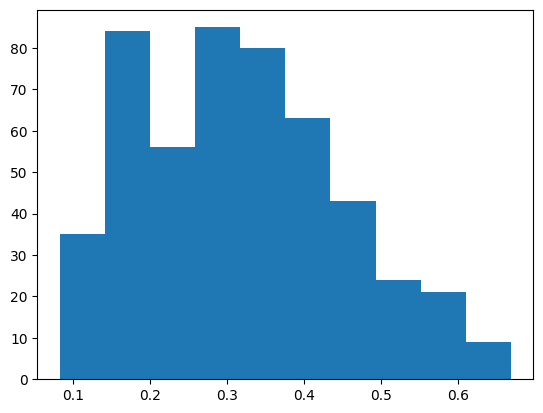

In [ ]:
plt.hist(prob_D)

#### Generamos Y:

In [ ]:
eps = np.random.normal(loc=0, scale=sigma, size=N)
Y = beta0 + tau*D + beta1*X1 + beta2*X2 + eps

In [ ]:
#Construimos nuestro DataFrame:
sim_data = pd.DataFrame({
    'Y': Y,
    'D': D,
    'X1': X1,
    'X2': X2
})


print(sim_data.head())

           Y  D    X1   X2
0  36.642050  0  14.0  2.0
1  37.867212  0  10.0  4.0
2  48.394439  0  10.0  9.0
3  34.963063  0  12.0  1.0
4  52.828744  1  14.0  9.0


### 3. Ajustamos un modelos de regresión lineal con Statsmodel

#### ¿Qué pasaría si sólo midiéramos el "efecto" del tratamiento?

In [ ]:
outcome = sim_data['Y']
predictors = sim_data[['D']]  ### Observemos que X_1, X_2 no están siendo consideradas

# Añadimos el intercepto
predictors = sm.add_constant(predictors)

# Ajustamos una regresión mediante MCO
model = sm.OLS(outcome, predictors)
results = model.fit()

# Resultados
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     199.7
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.25e-38
Time:                        01:18:58   Log-Likelihood:                -1631.9
No. Observations:                 500   AIC:                             3268.
Df Residuals:                     498   BIC:                             3276.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9274      0.349    117.267      0.0

### Interpretación del output de statsmodel (EJEMPLO):

# 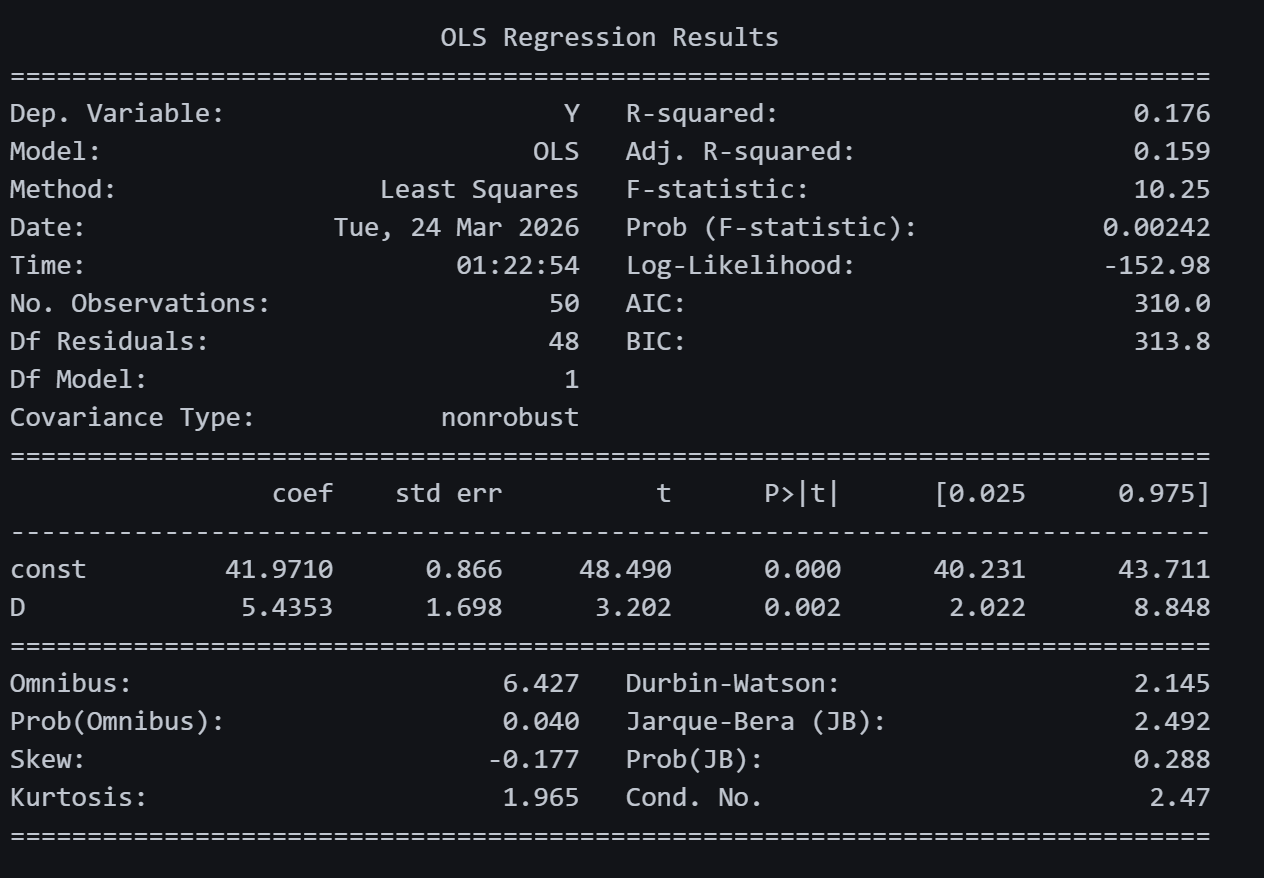

- El intercepto es el promdio del grupo control $E[Y|D=0] = 41.97$.

- El tratamiento $D=5.435$ es el efecto promedio del tratamiento $\beta_1 = E[Y|D=1] - E[Y|D=0]$. Entonces $E[Y|D=1 ]= 41.93+5.43 \approx 47.41$. Esto es, el tratamiento incrementa a métrica en $+5.43$.

- **El P-value del tratamiento es $0.002$, que está muy por debajo de $0.05$** (umbral de significancia). Esto es que la variable es significativa para lo que estamos estudiando.

Con esto podemos concluir que rechazamos la hipótesis nula [$H_0:\beta_1=0$], ya que la significancia es la probabilidad de que rechazando la hipótesis nula nos equivoquemos; un p-value muy pequeño **es evidencia fuerte de que el tratamiento sí tiene efecto**

- Bondad de ajuste: R-squared de 0.176. Indica qué porcentaje de variabilidad de Y se explica por D. No es mucho, pero tampoco es poco. La variabiliad es qué tanta iformación contiene una variable sobre otra. En este caso, D explica el 17.6% de la variabilidad de Y, lo que sugiere que D tiene una relación significativa con Y.

Siempre que metamos más variables predictoras, R^2 puede crecer arbitrariamente, por eso se utiliza la R^2-ajustada que penaliza la cantidad de variables.

[Dado que no estamos controlando por los confounders (X1 y X2), es probable que el coeficiente de D esté sesgado debido a la omisión de estas variables importantes.]

- Intervalo de confianza al 95%: $[2. 02, 8.85]$. Indica que el efecto verdadero está entre $2.02$ y $8.85$.

Algo preocupate ocurriría cuando el 0 aparece dentro del intervalo de confianza, lo que indicaría que no podemos descartar la posibilidad de que el efecto del tratamiento sea nulo.

- El estadístico f es una medida de la calidad del ajuste del modelo, y en este caso, el valor de 10.5 indica que el modelo es significativo en su conjunto. Se espera que el estadístico f sea grande y su correspondiente p-value muy pequeño ($en este caso 0.002$). Indica que es correcto rechazar la hipótesis nula donde todos los coeficientes son cero, la hipótesis alternativa indica que al menos uno de los coeficientes no es cero.


**La conclusión** es que en la ecuación
$$
Y
= \beta_0
+ \tau \, D
+ \beta_1 \, X_1
+ \beta_2 \, X_2
+ \varepsilon
$$

El valor de $\tau = 5.43$ y $\beta = 41.97$. (casi el doble del intercepto)

- ¿Esos 5434 usd anuales adicionales son atribuibles a la capacitación?
- ¿Por qué se aleja tanto de $\beta=20$?

Debe haber más variables relevantes que afectan tanto a la asignación del tratamiento, como al ingreso que no estamos incorporando al modelo.



## Incorporando los confounders $X_1$ y $X_2$

In [ ]:
# Definimos outcome (Y) y predictoras (X)
outcome = sim_data['Y']
predictors = sim_data[['D', 'X1', 'X2']]

# Añadimos el intercepto
predictors = sm.add_constant(predictors)

# Ajustamos una regresión mediante MCO
model = sm.OLS(outcome, predictors)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     4723.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:18:58   Log-Likelihood:                -869.56
No. Observations:                 500   AIC:                             1747.
Df Residuals:                     496   BIC:                             1764.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.0859      0.339     59.256      0.0

#### Interpretación del coeficiente asociado a D

In [ ]:
### SESGO DE SELECCIÓN: el tratamiento no es aleatorio respecto a los resultados potenciales;
# depende de confusores que también afectan Y -> se rompe

#estamos comparando personas con el mismo nivel de educación y experiencia,
# pero que difieren únicamente en si recibieron o no el tratamiento.
# Esto elimina el sesgo que veíamos en la regresión simple
# (donde obteníamos ~9.k en lugar de ~5.4k)

## las personas con más educación/experiencia tenían mayor probabilidad de inscribirse al programa

# y también ganan más de forma independiente.
# Sin controles, parte de ese efecto se atribuía erróneamente al tratamiento.


* Podemos decir que el efecto del tratamiento (programa de capacitación) es de 4.4k USD sobre el ingreso
* Es decir, en promedio, aquellos que tomaron el programa ganan 4.4k más que los que no lo tomaron una vez que CONTROLAMOS educación y experiencia

## 4. Diagnósticos de Causalidad

### 4.1 Soporte Común

#### Para ello primero calculamos la "Propensity Score":
El propensity score es la probabilidad de recibir el tratamiento dado las covariables:
$$
P(D=1|X_1,X_2)
$$

Imagina que quieres comparar el salario de dos personas: una con maestría que tomó el programa, y una sin maestría que no lo tomó. No es una comparación justa porque difieren en educación.
El propensity score dice: "ambas tenían una probabilidad de 0.3 de tomar el programa dadas sus características". Eso las hace comparables, aunque una haya tomado el programa y la otra no.

In [ ]:
# Ajustando una regresión logística para el tratamiento
X_logit = sim_data[["X1", "X2"]]
y_logit = sim_data["D"]

logit_model = LogisticRegression(fit_intercept=True, solver='lbfgs')
logit_model.fit(X_logit, y_logit)

# Calculando probabilidades
prop_score = logit_model.predict_proba(X_logit)[:, 1]

sim_data["propensity_score"] = prop_score


#### Visualizando intersección (overlap)

Graficando la distribución de las probabilidades para aquellos que recibieron tratamiento (D=1) vs aquellos que no (D=0). Idealmente, queremos que las distribuciones tengas superposición.  

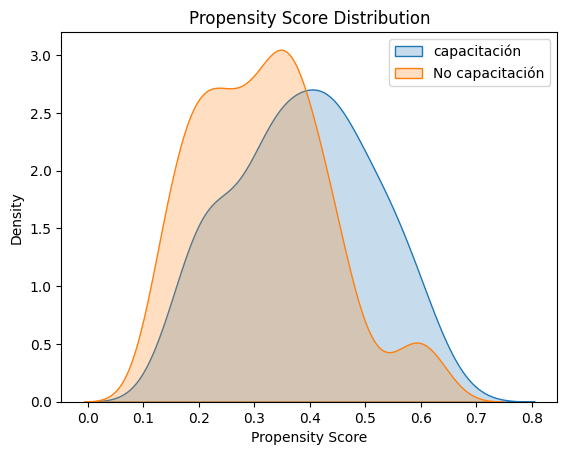

In [ ]:
sns.kdeplot(data=sim_data[sim_data["D"]==1], x="propensity_score", fill=True, label="capacitación")
sns.kdeplot(data=sim_data[sim_data["D"]==0], x="propensity_score", fill=True, label="No capacitación")
plt.title("Propensity Score Distribution")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()


In [ ]:
#Comentario: hay "buena" superposición?

#El rango de propensity scores es estrecho en ambos grupos: tratados entre 0.22 y 0.38,
# controles entre 0.17 y 0.33. Esto refleja que, dado el proceso generador, nadie tiene una
# probabilidad de tratamiento muy alta.
# La región de soporte común efectivo es [0.22, 0.33], lo que deja fuera a
# una parte del grupo control con scores muy bajos (que no tienen contraparte comparable
# en tratados).

##  la superposición no es ideal, pero es suficiente para proceder. El recorte de pesos
# extremos que se aplica más adelante (percentil 1-99) es precisamente la respuesta correcta a este diagnóstico.

## Inverse probability weighting

In [ ]:
# IPTW weights:  w = 1 / p(D=1|X) para tratamiento D=1,  w = 1 / [1 - p(D=1|X)] para los no tratados

sim_data["weight"] = np.where(sim_data["D"] == 1,
                              1 / sim_data["propensity_score"],
                              1 / (1 - sim_data["propensity_score"]))

# Media ponderada de X1 en tratados vs no tratados:

treated_weighted_mean_X1   = np.average(sim_data.loc[sim_data["D"]==1, "X1"],
                                        weights=sim_data.loc[sim_data["D"]==1, "weight"])
untreated_weighted_mean_X1 = np.average(sim_data.loc[sim_data["D"]==0, "X1"],
                                        weights=sim_data.loc[sim_data["D"]==0, "weight"])

print("Weighted Mean of X1 for Treated:   ", treated_weighted_mean_X1)
print("Weighted Mean of X1 for Untreated: ", untreated_weighted_mean_X1)

# Media ponderada de X2 en tratados vs no tratados:

treated_weighted_mean_X2   = np.average(sim_data.loc[sim_data["D"]==1, "X2"],
                                        weights=sim_data.loc[sim_data["D"]==1, "weight"])
untreated_weighted_mean_X2 = np.average(sim_data.loc[sim_data["D"]==0, "X2"],
                                        weights=sim_data.loc[sim_data["D"]==0, "weight"])

print("Weighted Mean of X2 for Treated:   ", treated_weighted_mean_X2)
print("Weighted Mean of X2 for Untreated: ", untreated_weighted_mean_X2)

Weighted Mean of X1 for Treated:    11.911832456003593
Weighted Mean of X1 for Untreated:  11.953619695921178
Weighted Mean of X2 for Treated:    5.081996185401866
Weighted Mean of X2 for Untreated:  5.054004198705292


In [ ]:
## Volver a asignar D con estos valores
## Verificar el nuevo ATE

---
# 5. Resultados Potenciales y Contrafactuales

## ¿Qué es un contrafactual?

El **contrafactual** de un individuo es el resultado que *habría obtenido* bajo el escenario alternativo al que vivió. Formalmente, el marco de **Resultados Potenciales** (*Potential Outcomes Framework*, Rubin 1974) define:

- $Y_i(1)$: ingreso del individuo $i$ **si hubiera tomado** el programa de capacitación.
- $Y_i(0)$: ingreso del individuo $i$ **si no hubiera tomado** el programa.

El **efecto causal individual** sería:
$$\delta_i = Y_i(1) - Y_i(0)$$

El **problema fundamental de la causalidad** es que solo observamos *uno* de los dos resultados potenciales:
$$Y_i^{obs} = D_i \cdot Y_i(1) + (1 - D_i) \cdot Y_i(0)$$

El resultado no observado es el **contrafactual**. Nunca lo vemos directamente; tenemos que estimarlo.

### ¿Por qué importa?

En la sección anterior trabajamos con $Y$ observado. Con contrafactuales podemos:
1. Calcular el efecto causal **para cada individuo** (ITE: *Individual Treatment Effect*).
2. Visualizar directamente el sesgo de selección.
3. Comparar qué tan bien recupera cada método ($\hat{\tau}$) el efecto verdadero.



| Cantidad | Definición | ¿Observable? |
|---|---|---|
| $Y_i(1)$ | Ingreso bajo tratamiento | Solo si $D_i=1$ |
| $Y_i(0)$ | Ingreso bajo control | Solo si $D_i=0$ |
| $\delta_i = Y_i(1)-Y_i(0)$ | Efecto individual | **Nunca** |
| $\tau = E[\delta_i]$ | ATE promedio | Solo estimable |


## 5.1 Simulación: Generamos *ambos* resultados potenciales

En una simulación tenemos el privilegio de **conocer el proceso generador de datos**, por lo que podemos construir $Y_i(0)$ e $Y_i(1)$ para cada individuo. Esto nos permite observar el contrafactual que en la realidad nunca veríamos.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(123)

#  Parámetros verdaderos
N     = 500
beta0 = 20    # intercepto: ingreso base
tau   = 5     # efecto causal verdadero del programa
beta1 = 1     # efecto de la educación
beta2 = 2     # efecto de la experiencia
sigma = 1.5   # ruido del proceso

# Covariables (confounders)
X1 = np.random.uniform(8, 16, size=N).round()   # educación en años
X2 = np.random.uniform(0, 10, size=N).round()   # experiencia en años

# ── Asignación NO aleatoria (escenario observacional con confounders)
logit  = -4 + 0.2*X1 + 0.15*X2  ### La educación tiene más peso sobre D
prob_D = 1 / (1 + np.exp(-logit))
D      = np.random.binomial(n=1, p=prob_D, size=N) ### La asignación sigue siendo binomial pero p podría ser distinta de 005

# ── Término de error (el mismo para ambos mundos posibles)
# Usamos el MISMO eps para Y(0) e Y(1): solo cambia si recibe o no tratamiento
eps = np.random.normal(0, sigma, size=N)

# ── RESULTADOS POTENCIALES: el corazón del marco contrafactual
# Y(0): ingreso que tendría el individuo i si NO tomara el programa
Y0 = beta0 + beta1*X1 + beta2*X2 + eps           # mundo posible sin tratamiento

# Y(1): ingreso que tendría el individuo i si SÍ tomara el programa
Y1 = beta0 + tau + beta1*X1 + beta2*X2 + eps     # mundo con tratamiento
                                                # τ es precisamentelo único que diferencia los dos mundos


# Nota: Y1 - Y0 = tau = 5 para TODOS (efecto homogéneo por construcción)

# ── Outcome observado: solo vemos uno de los dos mundos
Y_obs = D * Y1 + (1 - D) * Y0   # si D=1 observamos Y(1), si D=0 observamos Y(0)

# ── Efecto causal individual verdadero
ITE = Y1 - Y0   # en simulación lo conocemos; en realidad es imposible observarlo

# ── DataFrame completo con contrafactuales
cf_data = pd.DataFrame({
    'Y_obs': Y_obs,   # lo que observamos
    'Y0':    Y0,      # contrafactual/observado según D
    'Y1':    Y1,      # contrafactual/observado según D
    'ITE':   ITE,     # efecto individual verdadero
    'D':     D,
    'X1':    X1,
    'X2':    X2,
    'prob_D': prob_D
})

# Columnas que indican si el valor es observado o contrafactual
cf_data['Y1_observable'] = np.where(D == 1, 'Observado', 'Contrafactual')
cf_data['Y0_observable'] = np.where(D == 0, 'Observado', 'Contrafactual')

print('Shape:', cf_data.shape)
print(f'Tratados (D=1): {D.sum()}  |  Controles (D=0): {(1-D).sum()}')
print(f'ATE verdadero (tau):          {tau}')
print(f'ATE desde ITE (mean Y1-Y0):   {ITE.mean():.4f}')
print()
print(cf_data[['Y_obs','Y0','Y1','ITE','D','X1','X2']].head(8).round(2))


Shape: (500, 10)
Tratados (D=1): 170  |  Controles (D=0): 330
ATE verdadero (tau):          5
ATE desde ITE (mean Y1-Y0):   5.0000

   Y_obs     Y0     Y1  ITE  D    X1   X2
0  36.64  36.64  41.64  5.0  0  14.0  2.0
1  37.87  37.87  42.87  5.0  0  10.0  4.0
2  48.39  48.39  53.39  5.0  0  10.0  9.0
3  34.96  34.96  39.96  5.0  0  12.0  1.0
4  52.83  47.83  52.83  5.0  1  14.0  9.0
5  41.61  41.61  46.61  5.0  0  11.0  5.0
6  44.52  44.52  49.52  5.0  0  16.0  4.0
7  40.51  40.51  45.51  5.0  0  13.0  3.0


## 5.2 El Problema Fundamental de la Causalidad

Para cada individuo **solo observamos uno** de los dos resultados potenciales. La celda siguiente visualiza esto: las celdas grises son los valores que **nunca podemos ver** en datos reales.

In [ ]:
# ── Tabla ilustrativa del problema fundamental ────────────────────────────────
# Mostramos 10 individuos: qué observamos y qué es contrafactual

muestra = cf_data[['D','Y0','Y1','ITE','Y0_observable','Y1_observable']].head(10).copy()
muestra.index.name = 'Individuo'

print('=== Lo que observamos vs. lo que es contrafactual ===')
print(f'{"i":>4} {"D":>4} {"Y(0)":>10} {"Y(1)":>10} {"ITE":>8}  {"Y(0) es":>14}  {"Y(1) es":>14}')
print('-' * 70)

for i, row in muestra.iterrows():
    y0_tag = '← OBSERVADO' if row['D'] == 0 else '[contrafact.]'
    y1_tag = '← OBSERVADO' if row['D'] == 1 else '[contrafact.]'
    print(f'{i:>4} {int(row["D"]):>4} {row["Y0"]:>10.2f} {row["Y1"]:>10.2f} '
          f'{row["ITE"]:>8.2f}  {y0_tag:>14}  {y1_tag:>14}')

print('-' * 70)
print('Nota: ITE = Y(1) - Y(0) = tau = 5 para todos (efecto homogéneo).')
print('En datos reales, ITE nunca es observable.')


=== Lo que observamos vs. lo que es contrafactual ===
   i    D       Y(0)       Y(1)      ITE         Y(0) es         Y(1) es
----------------------------------------------------------------------
   0    0      36.64      41.64     5.00     ← OBSERVADO   [contrafact.]
   1    0      37.87      42.87     5.00     ← OBSERVADO   [contrafact.]
   2    0      48.39      53.39     5.00     ← OBSERVADO   [contrafact.]
   3    0      34.96      39.96     5.00     ← OBSERVADO   [contrafact.]
   4    1      47.83      52.83     5.00   [contrafact.]     ← OBSERVADO
   5    0      41.61      46.61     5.00     ← OBSERVADO   [contrafact.]
   6    0      44.52      49.52     5.00     ← OBSERVADO   [contrafact.]
   7    0      40.51      45.51     5.00     ← OBSERVADO   [contrafact.]
   8    1      49.21      54.21     5.00   [contrafact.]     ← OBSERVADO
   9    0      40.22      45.22     5.00     ← OBSERVADO   [contrafact.]
----------------------------------------------------------------------
N

## 5.3 Visualizando el Sesgo de Selección con Contrafactuales

Con los resultados potenciales podemos **descomponer** la diferencia observada entre grupos:

$$\underbrace{E[Y^{obs}|D=1] - E[Y^{obs}|D=0]}_{\text{diferencia observada}} = \underbrace{\tau}_{\text{efecto causal}} + \underbrace{E[Y(0)|D=1] - E[Y(0)|D=0]}_{\text{sesgo de selección}}$$

El **sesgo de selección** es la diferencia en los outcomes *base* ($Y(0)$) entre tratados y controles. Si los grupos fueran comparables (A/B test), este término sería cero.

 DESCOMPOSICIÓN DE LA DIFERENCIA OBSERVADA
  Diferencia observada (naive):   8.459
  = Efecto causal verdadero (tau): 5.000
  + Sesgo de selección:            3.459
  Verificación: 5.000 + 3.459 = 8.459

El sesgo existe porque los tratados tendrían mayor
ingreso incluso SIN el programa (mayor educación/experiencia base).


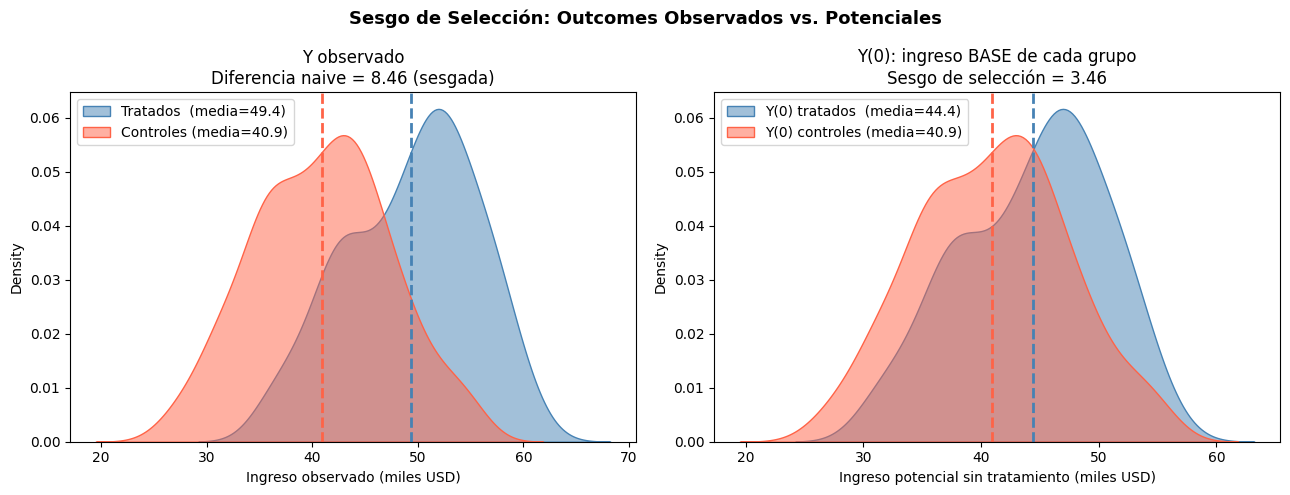

In [ ]:
# ── Descomposición del sesgo de selección

tratados  = cf_data[cf_data['D'] == 1]
controles = cf_data[cf_data['D'] == 0]

# Diferencia observada (lo que mediríamos sin ajuste)
diff_obs = tratados['Y_obs'].mean() - controles['Y_obs'].mean()

# Efecto causal verdadero
ate_verdadero = tau

# Sesgo de selección: diferencia en Y(0) entre grupos
# Los tratados tienen mayor Y(0) base porque tienen más educación/experiencia
sesgo = tratados['Y0'].mean() - controles['Y0'].mean()

print('=' * 55)
print(' DESCOMPOSICIÓN DE LA DIFERENCIA OBSERVADA')
print('=' * 55)
print(f'  Diferencia observada (naive):   {diff_obs:.3f}')
print(f'  = Efecto causal verdadero (tau): {ate_verdadero:.3f}')
print(f'  + Sesgo de selección:            {sesgo:.3f}')
print(f'  Verificación: {ate_verdadero:.3f} + {sesgo:.3f} = {ate_verdadero + sesgo:.3f}')
print('=' * 55)
print()
print('El sesgo existe porque los tratados tendrían mayor')
print('ingreso incluso SIN el programa (mayor educación/experiencia base).')

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sesgo de Selección: Outcomes Observados vs. Potenciales', fontsize=13, fontweight='bold')

# Panel izquierdo: Y observado (lo que vemos sin contrafactuales)
ax = axes[0]
sns.kdeplot(data=tratados,  x='Y_obs', ax=ax, fill=True,
            color='steelblue', alpha=0.5, label=f'Tratados  (media={tratados["Y_obs"].mean():.1f})')
sns.kdeplot(data=controles, x='Y_obs', ax=ax, fill=True,
            color='tomato',    alpha=0.5, label=f'Controles (media={controles["Y_obs"].mean():.1f})')
ax.axvline(tratados['Y_obs'].mean(),  color='steelblue', linestyle='--', linewidth=2)
ax.axvline(controles['Y_obs'].mean(), color='tomato',    linestyle='--', linewidth=2)
ax.set_title(f'Y observado\nDiferencia naive = {diff_obs:.2f} (sesgada)')
ax.set_xlabel('Ingreso observado (miles USD)')
ax.legend()

# Panel derecho: Y(0) para ambos grupos (revela el sesgo base)
ax2 = axes[1]
sns.kdeplot(data=tratados,  x='Y0', ax=ax2, fill=True,
            color='steelblue', alpha=0.5, label=f'Y(0) tratados  (media={tratados["Y0"].mean():.1f})')
sns.kdeplot(data=controles, x='Y0', ax=ax2, fill=True,
            color='tomato',    alpha=0.5, label=f'Y(0) controles (media={controles["Y0"].mean():.1f})')
ax2.axvline(tratados['Y0'].mean(),  color='steelblue', linestyle='--', linewidth=2)
ax2.axvline(controles['Y0'].mean(), color='tomato',    linestyle='--', linewidth=2)
ax2.set_title(f'Y(0): ingreso BASE de cada grupo\nSesgo de selección = {sesgo:.2f}')
ax2.set_xlabel('Ingreso potencial sin tratamiento (miles USD)')
ax2.legend()

plt.tight_layout()
plt.show()


## 5.4 Comparación de Métodos: ¿Quién Recupera Mejor el ATE Verdadero?

Ahora estimamos el ATE con cuatro métodos y comparamos contra $\tau = 5$
(que conocemos porque simulamos el proceso generador de datos). El objetivo es ver cuánto se aleja cada método del valor verdadero y entender por qué.

1. Diferencia naive Simplemente restamos la media de Y observado entre tratados y controles, sin ningún ajuste. Es el estimador más intuitivo pero el más sesgado: como los tratados tienen más educación y experiencia, parte de la diferencia en ingresos se debe a esas ventajas previas, no al programa. Sobreestima τ.

2. Regresión simple $Y \sim D$ Equivalente al método naive en términos de lo que estima: el coeficiente de $D$ captura el efecto del programa
más el sesgo de selección. La regresión no añade nada nuevo aquí porque no estamos controlando por ninguna variable que rompa la correlación entre $D$ y los confounders.

3. Regresión con controles $Y\sim D+X_1+X_2$
 incluir $X_1$ y $X_2$ en el modelo, el coeficiente de $D$ se interpreta como el efecto del programa
manteniendo fijas la educación y la experiencia. Esto elimina el sesgo de selección condicionalmente y debería acercarse mucho más a $\tau = 5$.

4. Contrafactual directo (oráculo) Calculamos $E[Yi(1)]−E[Yi(0)]$ usando los resultados potenciales completos que generamos en la simulación. Es el estimador perfecto porque conocemos
ambos mundos para cada individuo — algo imposible en datos reales. Sirve como techo de referencia: ningún método estadístico puede superar esta estimación porque usa información que en la práctica nunca está disponible.

In [ ]:
from sklearn.linear_model import LogisticRegression

resultados = {}  # guardamos todos los estimados aquí

# ── Método 1: Diferencia naive de medias
# Compara directamente tratados vs controles sin ningún ajuste
# Está contaminado por el sesgo de selección
naive = tratados['Y_obs'].mean() - controles['Y_obs'].mean()
resultados['1. Naive (sin ajuste)'] = naive

# ── Método 2: Regresión simple Y ~ D
# Equivalente al naive; el coeficiente de D captura efecto + sesgo
reg_simple = sm.OLS(cf_data['Y_obs'],
                    sm.add_constant(cf_data['D'])).fit()
resultados['2. Regresión simple (Y ~ D)'] = reg_simple.params['D']

# ── Método 3: Regresión con controles Y ~ D + X1 + X2
# Al controlar por los confounders, eliminamos el sesgo de selección
reg_controles = sm.OLS(cf_data['Y_obs'],
                       sm.add_constant(cf_data[['D','X1','X2']])).fit()
resultados['3. Regresión con controles'] = reg_controles.params['D']

# ── Método 4: Contrafactual directo (solo posible en simulación)
# Calculamos E[Y(1)] - E[Y(0)] usando los resultados potenciales completos
## la estimación perfecta que nunca podemos hacer en realidad
ate_oraculo = cf_data['Y1'].mean() - cf_data['Y0'].mean()
resultados['4. Contrafactual directo (oráculo)'] = ate_oraculo

# ── Resumen comparativo
print('=' * 65)
print(f'  ATE VERDADERO (tau):   {tau:.4f}')
print('=' * 65)
print(f'{"Método":<40} {"Estimado":>10} {"Error":>10}')
print('-' * 65)
for metodo, est in resultados.items():
    error = est - tau
    print(f'{metodo:<40} {est:>10.4f} {error:>+10.4f}')
print('=' * 65)


  ATE VERDADERO (tau):   5.0000
Método                                     Estimado      Error
-----------------------------------------------------------------
1. Naive (sin ajuste)                        8.4594    +3.4594
2. Regresión simple (Y ~ D)                  8.4594    +3.4594
3. Regresión con controles                   5.0666    +0.0666
4. Contrafactual directo (oráculo)           5.0000    +0.0000


## 5.6 Análisis Comparativo: Con y Sin Contrafactuales

### ¿Qué ganamos al pensar en términos de contrafactuales?

| Dimensión | Sin contrafactuales | Con contrafactuales |
|---|---|---|
| **Pregunta** | ¿Hay correlación entre $D$ e $Y$? | ¿Cuál sería el ingreso de $i$ si cambiara solo $D$? |
| **Estimador** | $\bar{Y}_{D=1} - \bar{Y}_{D=0}$ | $E[Y(1) - Y(0)]$ |
| **Sesgo** | Alto si hay confounders | Cero (por definición) |
| **Observable** | Siempre | Solo en simulación |
| **Utilidad** | Describe asociación | Identifica causalidad |

### ¿Por qué el método naive sobreestima el efecto?

Porque los tratados no son comparables con los controles: tienen más educación y experiencia, por lo que ganarían más **incluso sin el programa**. La diferencia observada mezcla el efecto causal con esa ventaja previa.

### ¿Por qué la regresión con controlando las variables de confusión se acerca al verdadero?

Al incluir $X_1$ y $X_2$ en el modelo, el coeficiente de $D$ se interpreta *manteniendo constantes* la educación y la experiencia. Esto elimina el sesgo de selección condicionalmente, aproximando la comparación contrafactual ideal.

### ¿Por qué el estimador contrafactual es exactamente $\tau = 5$?

Porque usamos directamente $E[Y_i(1)] - E[Y_i(0)]$ sobre toda la población. Eliminamos el problema fundamental: conocemos ambos resultados potenciales para cada individuo. Esto solo es posible en simulación y sirve como referencia de lo que los métodos estadísticos intentan aproximar.

### Conclusión

El marco de resultados potenciales no es un método estadístico en sí mismo, sino un lenguaje conceptual que clarifica lo que queremos estimar. Estos métodos son las herramientas para *aproximar* ese ideal cuando el contrafactual no es observable (que es siempre en datos reales).
